# TERN photosynthetic pathways: % C3 / C4 plant cover at one TERN plot

**Paper:** Munroe, Guerin *et al.* (2021) *"The photosynthetic pathways of plant species surveyed in Australia's national terrestrial monitoring network"*, **Scientific Data 8:97**, https://doi.org/10.1038/s41597-021-00877-z

**Source code:** authors' R tutorial (Supplementary File 1 of the paper) run with the authors' R package [ausplotsR](https://github.com/ternaustralia/ausplotsR) (GPL-3, CRAN **2.0.5**).

**Data:** TERN photosynthetic pathway dataset, **version 1 (2020) XLSX** — the version matching the published 2428-species dataset — from [TERN portal record 21821](https://portal.tern.org.au/photosynthetic-pathways-plant-surveillance-plots/21821) (DOI 10.25901/k61f-yz90), CC-BY 4.0. TERN plot data are also CC-BY 4.0.

**Scope / status:** PARTIAL demonstration — the paper's own usage-note tutorial (Supplementary File 1) executed for **one TERN plot** (not the full 541-plot database). The optional environmental-raster step of the tutorial is omitted (it requires a user-supplied CSIRO/SLGA raster file). All scientific computation here is the **authors' own R code** (tutorial lines 49–148, adapted as documented below); the Python cells only install R and orchestrate `Rscript`. AI-assisted orchestration only; the analysis logic is copied from the authors' supplement.

**日本語:** このノートブックは論文付属の R チュートリアル（Supplementary File 1）を、著者自身の R パッケージ *ausplotsR* とともに Colab 上の `Rscript` で実行するものです。対象は **TERN プロット 1 つ**の部分的なデモで、全 541 プロットの解析ではありません。チュートリアル後半の環境ラスタ抽出（任意）は省略しています。解析ロジックは著者コードのほぼ引用で、Python 部分は R の導入・実行の補助のみです。

In [ ]:
import shutil, subprocess, sys

# Ensure R is available (Colab CPU images may not include it)
# libgmp-dev: required to compile the 'rcdd' dependency of betapart (R may be preinstalled without it)
subprocess.run(["apt-get", "update", "-qq"], check=True)
if not shutil.which("Rscript"):
    print("R not found; installing r-base-core via apt ...")
    subprocess.run(["apt-get", "install", "-y", "-qq", "r-base-core"], check=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "libgmp-dev"], check=True)
r = subprocess.run(["Rscript", "-e", "cat(R.version.string)"],
                   capture_output=True, text=True, check=True, timeout=300)
print(r.stdout)

R version 4.6.1 (2026-06-24)


## Runtime selection — **CPU only**（実行ランタイム：CPU を選択してください）

This is a small R data-analysis task (≈1,010 point-intercepts for one plot). **No GPU is used anywhere in the paper's method.** Select *Runtime → Change runtime type → CPU*.

**Run all** takes roughly **15–25 minutes** on a fresh CPU runtime (R package installation dominates). Downloads: R packages (~200 MB) + the pathway XLSX (~2 MB).

**日本語:** GPU は不要です。CPU ランタイムを選択し、すべてのセルを実行してください。所要時間は目安 15〜25 分（R パッケージ導入が大半）、ダウンロード約 200 MB + 数 MB。

In [ ]:
import subprocess

install_r = r'''
options(warn = 1, timeout = 1200)
repo <- "https://cloud.r-project.org"
deps <- c("ggplot2","mapdata","vegan","plyr","R.utils","httr","jsonlite",
          "gtools","jose","betapart","curl","r2r","stringr","progress",
          "readxl","reshape2","data.table")
install.packages(deps, repos = repo)
# Exact author-package version pin (paper-era release, GPL-3).
# 2.0.5 is the current CRAN release -> src/contrib; if superseded it moves to Archive.
ok <- FALSE
for (u in c("https://cran.r-project.org/src/contrib/ausplotsR_2.0.5.tar.gz",
            "https://cran.r-project.org/src/contrib/Archive/ausplotsR/ausplotsR_2.0.5.tar.gz")) {
  try({ install.packages(u, repos = NULL, type = "source"); ok <- requireNamespace("ausplotsR", quietly = TRUE) }, silent = TRUE)
  if (ok) break
}
if (!ok) stop("Could not install ausplotsR 2.0.5 from CRAN.")
for (p in c("ausplotsR","readxl","reshape2","data.table"))
  cat(p, as.character(packageVersion(p)), "\n")
'''
open("/content/install_pkgs.R", "w").write(install_r)
proc = subprocess.Popen(["Rscript", "/content/install_pkgs.R"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end="")
proc.wait(timeout=3600)
if proc.returncode != 0:
    raise RuntimeError(f"R package installation failed: exit {proc.returncode}")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


also installing the dependencies ‘abind’, ‘magic’, ‘lpSolve’, ‘linprog’, ‘RcppProgress’, ‘iterators’, ‘maps’, ‘permute’, ‘R.oo’, ‘R.methodsS3’, ‘ape’, ‘fastmatch’, ‘geometry’, ‘picante’, ‘rcdd’, ‘doSNOW’, ‘foreach’, ‘snow’, ‘itertools’, ‘minpack.lm’

trying URL 'https://cloud.r-project.org/src/contrib/abind_1.4-8.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/magic_1.6-1-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/lpSolve_5.6.23.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/linprog_0.9-6.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppProgress_0.4.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/maps_3.4.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/permute_0.9-10.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.oo_1.27.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.methodsS3_1.8.2.tar.gz'
tr

trying URL 'https://cloud.r-project.org/src/contrib/httr_1.4.9.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/jsonlite_2.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/gtools_3.9.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/jose_2.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/betapart_1.6.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/curl_8.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/r2r_0.1.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/stringr_1.6.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/progress_1.2.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/readxl_1.5.0.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/reshape2_1.4.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/data.table_1.18.6.1.tar.gz'


* installing *source* package ‘abind’ ...
** this is package ‘abind’ version ‘1.4-8’
** package ‘abind’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** byte-compile and prepare package for lazy loading


** help
*** installing help indices
** building package indices


...

** help
*** installing help indices
** building package indices


** installing vignettes
** testing if installed package can be loaded from temporary location


** testing if installed package can be loaded from final location


** testing if installed package keeps a record of temporary installation path
* DONE (ausplotsR)


ausplotsR 2.0.5 
readxl 1.5.0.1 
reshape2 1.4.5 
data.table 1.18.6.1 


## Install the authors' R package *ausplotsR* (pinned CRAN 2.0.5) and tutorial helpers

We pin **ausplotsR 2.0.5** (CRAN, 2023-11-17, GPL-3; the release matching the paper's method — `get_ausplots` single-plot filtering and `species_table(m_kind=, species_name=)` used here are unchanged through master 2.0.6). Its dependencies are installed from CRAN first, then the exact 2.0.5 source tarball. `readxl` reads the paper-version XLSX; `reshape2`/`data.table`/`plyr` are used by the authors' tutorial itself.

**日本語:** 論文の手法に対応するバージョンに固定した *ausplotsR* 2.0.5 と、チュートリアルで使うヘルパーパッケージを導入します（数分かかります）。

In [ ]:
import hashlib, zipfile, urllib.request

URL = ("https://shared.tern.org.au/attachment/1e16257d-57ae-48dd-bbad-5701e72a9f6d/"
       "Photosynthetic_pathways_of_plant_TERN_v1_2020.xlsx")
XLSX = "/content/Photosynthetic_pathways_v1_2020.xlsx"

urllib.request.urlretrieve(URL, XLSX)  # dataset bytes: Colab VM only
raw = open(XLSX, "rb").read()
assert zipfile.is_zipfile(XLSX), "Downloaded file is not a valid XLSX (OOXML) container"
with zipfile.ZipFile(XLSX) as z:
    assert "xl/workbook.xml" in z.namelist(), "Missing xl/workbook.xml - not a real XLSX"
print("source:", URL)
print("bytes:", len(raw))
print("sha256:", hashlib.sha256(raw).hexdigest())

source: https://shared.tern.org.au/attachment/1e16257d-57ae-48dd-bbad-5701e72a9f6d/Photosynthetic_pathways_of_plant_TERN_v1_2020.xlsx
bytes: 219949
sha256: 402dbffcaada03d38f95724f39e2780e69ca0031d51de35d6e921b2104e28458


## Acquire the paper-version photosynthetic pathway dataset (v1, 2020 XLSX)

Downloaded **inside Colab** (dataset bytes never touch the host). We verify the XLSX container (valid ZIP/OOXML), record its SHA-256 and size. The current TERN portal serves a v2 (2024) CSV as primary; the **v1 2020 XLSX** is the exact dataset analysed in the paper.

**日本語:** 論文が解析したバージョン（v1, 2020）の XLSX を Colab 内でダウンロードし、ファイル署名・サイズ・SHA-256 を検証します。

In [ ]:
import subprocess

select_plot_r = r'''
library(ausplotsR)
# List plots containing Poaceae records via the package's own internal search
# resolver (the same function get_ausplots calls; unexported in CRAN 2.0.5, hence :::)
plots <- sort(unique(ausplotsR:::list_available_plots(Plot_IDs = "none", family_search = "Poaceae")))
cat("plots matching Poaceae:", length(plots), "\n")
if (length(plots) < 1) stop("No plots returned by list_available_plots; TERN API may be unreachable.")
chosen <- plots[1]                       # deterministic: first sorted plot ID
cat("chosen plot:", chosen, "\n")
writeLines(chosen, "/content/chosen_plot.txt")
'''
open("/content/select_plot.R", "w").write(select_plot_r)
r = subprocess.run(["Rscript", "/content/select_plot.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.stderr.strip():
    print(r.stderr, file=sys.stderr)
if r.returncode != 0:
    raise RuntimeError(f"select_plot.R failed: exit {r.returncode}")

plots matching Poaceae: 746 
chosen plot: NSABBS0001 



Loading required package: ggplot2
Loading required package: mapdata
Loading required package: maps
Calling the database. Please wait...
200



## Select one TERN plot deterministically

The full-database `get_ausplots()` of the tutorial downloads every plot's point-intercept table (gigabytes); for a single-example demonstration we restrict to **one plot** using the package's own `my.Plot_IDs` filter (R/get_ausplots.R:74-103 of the pinned commit). We pick the **first, alphabetically sorted** plot whose records include the family **Poaceae** (grasses contain many C3 and C4 species, giving a meaningful C3/C4 comparison). The selection is deterministic for a given database state and is printed for reproducibility. (CRAN 2.0.5 keeps this resolver unexported, so it is called with `ausplotsR:::` — the same internal function `get_ausplots` itself uses.)

**日本語:** 全データベース取得は巨大すぎるため、パッケージ本体の `my.Plot_IDs` フィルタで 1 プロットに限定します。Poaceae（イネ科）を含むプロットから、名前順で最初のものを決定論的に選びます。

In [ ]:
import subprocess

extract_r = r'''
library(ausplotsR)
plot_id <- readLines("/content/chosen_plot.txt")[1]
cat("TERN plot:", plot_id, "\n")
ap <- get_ausplots(my.Plot_IDs = plot_id, veg.PI = TRUE)   # site_info=TRUE default
if (is.null(ap)) stop("get_ausplots returned NULL: TERN API (swarmapi.ausplots.aekos.org.au) unreachable.")
cat("tables returned:", paste(names(ap), collapse = ", "), "\n")
veg <- ap$veg.PI
cat("point-intercept rows:", nrow(veg), "| unique plot visits:",
    length(unique(veg$site_unique)), "\n")
# Authors' tutorial line 86 (verbatim call):
species_cover <- species_table(veg, m_kind = "percent_cover", species_name = "GS")
cat("species-cover matrix dim (plots x species):", dim(species_cover)[1], "x", dim(species_cover)[2], "\n")
saveRDS(species_cover, "/content/species_cover.rds")
saveRDS(ap$site.info, "/content/site_info.rds")
cat(ap$citation, "\n")
'''
open("/content/extract_cover.R", "w").write(extract_r)
r = subprocess.run(["Rscript", "/content/extract_cover.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.stderr.strip():
    print(r.stderr, file=sys.stderr)
if r.returncode != 0:
    raise RuntimeError(f"extract_cover.R failed: exit {r.returncode}")

TERN plot: NSABBS0001 
tables returned: site.info, veg.PI, citation 
point-intercept rows: 1071 | unique plot visits: 1 
species-cover matrix dim (plots x species): 1 x 16 
TERN (2026) AusPlots ecosystem surveillance monitoring dataset (URL: http://aekos.org.au/). Obtained via the ausplotsR R package (URL: https://github.com/ternaustralia/ausplotsR), accessed 02 October 2026. 



Loading required package: ggplot2
Loading required package: mapdata
Loading required package: maps
Calling the database. Please wait...
200
User-supplied Plot_IDs located.
Calling the database. Please wait...
200
Calling the database. Please wait...
200
Warning message:
In species_table(veg, m_kind = "percent_cover", species_name = "GS") :
  No cover_type supplied, defaulting to 'PFC'



## Extract point-intercept data and compute % species cover (authors' tutorial, lines 59–86)

`get_ausplots(my.Plot_IDs = chosen)` pulls the plot's `$site.info` and `$veg.PI` point-intercept tables (~1,010 hits per plot) from the TERN server, then the authors' `species_table(veg.PI, m_kind="percent_cover", species_name="GS")` computes **% species cover** using the standardised genus-species rank (`"GS"`), exactly as the tutorial prescribes (Supplementary File 1 line 86).

**日本語:** 著者のチュートリアル通り、点頭法データ（$veg.PI）を取得し、`species_table` で種ごとの被度（%）を計算します（種名は属種レベル "GS"）。

In [ ]:
import subprocess

merge_r = r'''
library(readxl); library(reshape2); library(data.table); library(plyr)
species_cover <- readRDS("/content/species_cover.rds")

# --- authors' tutorial lines 98-103 (reshape to plot x species list) ---
names(species_cover) <- gsub("[.]", "_", names(species_cover))
sdf <- setDT(as.data.frame(species_cover), keep.rownames = TRUE)
names(sdf)[1] <- "site_unique"
cover_list <- reshape2::melt(sdf, id = "site_unique")
names(cover_list)[2] <- "Species.name"
names(cover_list)[3] <- "species_cover_value"

# --- pathway dataset (paper version v1 XLSX) ---
path_raw <- read_excel("/content/Photosynthetic_pathways_v1_2020.xlsx")
path <- as.data.frame(path_raw)
cat("pathway dataset columns:\n"); print(names(path_raw))
cat("pathway dataset rows:", nrow(path), "\n")
names(path) <- make.names(names(path))   # mirror read.csv name mangling of the tutorial

sp_col   <- grep("Species", names(path), value = TRUE)[1]
comb_col <- grep("combined", names(path), ignore.case = TRUE, value = TRUE)[1]
if (is.na(sp_col) || is.na(comb_col))
  stop("Could not locate species / combined-pathway columns in the XLSX; inspect printed column names.")
cat("species column:", sp_col, "| combined pathway column:", comb_col, "\n")
cat("pathway values in combined column:\n"); print(table(path[[comb_col]], useNA = "ifany"))

names(path)[match(sp_col, names(path))] <- "Species.name"
names(path)[match(comb_col, names(path))] <- "Photosynthetic_pathway"
# Apply the tutorial's '.' -> '_' normalisation to both sides, then merge
path$Species.name <- trimws(gsub("[.]", "_", path$Species.name))
cover_list$Species.name <- trimws(gsub("[.]", "_", cover_list$Species.name))
Pathway_assignment <- merge(cover_list, path[, c("Species.name", "Photosynthetic_pathway")],
                            by = "Species.name")
cat("species matched:", length(unique(Pathway_assignment$Species.name)), "of",
    length(unique(cover_list$Species.name)), "recorded in the plot\n")

# --- authors' tutorial lines 142-145 ---
C3_C4 <- subset(Pathway_assignment, Photosynthetic_pathway %in% c("C3", "C4"))
C3_C4_cover <- plyr::ddply(C3_C4, c("site_unique", "Photosynthetic_pathway"), summarise,
                           Total_Cover = sum(species_cover_value, na.rm = TRUE))
cat("\n% C3 / C4 species cover (per plot visit):\n")
print(C3_C4_cover)
saveRDS(C3_C4_cover, "/content/c3c4_cover.rds")
write.csv(C3_C4_cover, "/content/c3c4_cover.csv", row.names = FALSE)
'''
open("/content/merge_pathway.R", "w").write(merge_r)
r = subprocess.run(["Rscript", "/content/merge_pathway.R"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.stderr.strip():
    print(r.stderr, file=sys.stderr)
if r.returncode != 0:
    raise RuntimeError(f"merge_pathway.R failed: exit {r.returncode}")

pathway dataset columns:
 [1] "Species.name"                                                                                 
 [2] "genus"                                                                                        
 [3] "species epithet"                                                                              
 [4] "family"                                                                                       
 [5] "Species name comments"                                                                        
 [6] "Photosynthetic.pathway (confirmed using data from literature or TERN stable isotope analysis)"
 [7] "Photosynthetic.pathway (inferred from lineage)"                                               
 [8] "Photosynthetic pathway (combined)"                                                            
 [9] "Source"                                                                                       
[10] "Justification for inference based on lineage"               


Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following object is masked from ‘package:base’:

    %notin%




## Merge with the pathway dataset and compute % C3 / C4 cover (authors' tutorial, lines 98–145)

The authors' code reshapes the cover matrix to one row per (plot visit, species), merges it with the pathway dataset **by species name**, subsets the `"Photosynthetic.pathway..combined."` column (confirmed by literature **or** the paper's own δ¹³C isotope analysis) to `"C3"`/`"C4"`, and sums cover per plot with `plyr::ddply` (tutorial lines 142–145).

Adaptations (documented): the XLSX is read with `readxl` and `make.names()` reproduces `read.csv`'s name mangling; the species-name column and the *combined* pathway column are located by name pattern and their positions/names are printed; the tutorial's `.` → `_` species-name normalisation is applied to **both** sides. `reshape2::melt` replaces `reshape::melt` (equivalent for data frames).

**日本語:** 著者コード通り、被度表を縦長に整形し、 pathway データセットを種名で結合。combined 列の C3/C4 のみを取り出してプロットごとに合計します。XLSX 読み込みと列検出だけ最小限の適応を入れています。

saved /content/c3c4_cover.png and /content/c3c4_cover.csv



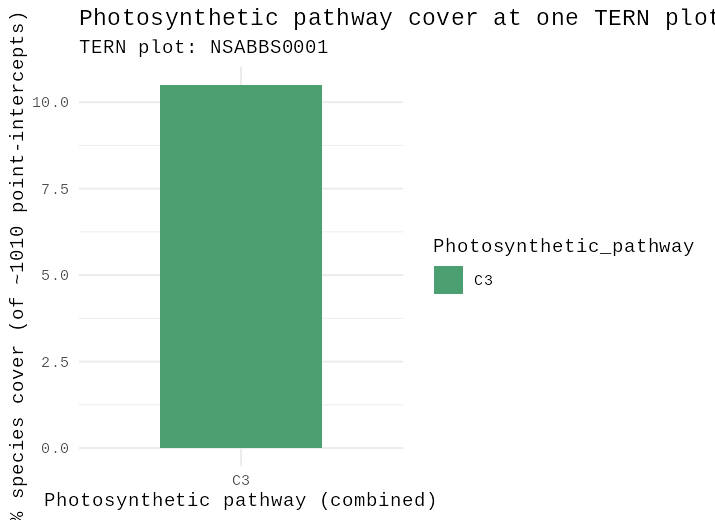

     site_unique Photosynthetic_pathway  Total_Cover
NSABBS0001-58580                     C3         10.5

CSV export: /content/c3c4_cover.csv


In [ ]:
import subprocess

plot_r = r'''
suppressMessages(library(ggplot2))
df <- readRDS("/content/c3c4_cover.rds")
plot_id <- readLines("/content/chosen_plot.txt")[1]
p <- ggplot(df, aes(Photosynthetic_pathway, Total_Cover, fill = Photosynthetic_pathway)) +
  geom_col(width = 0.6) +
  scale_fill_manual(values = c(C3 = "#4c9f70", C4 = "#d1495b")) +
  labs(title = "Photosynthetic pathway cover at one TERN plot",
       subtitle = paste("TERN plot:", plot_id),
       x = "Photosynthetic pathway (combined)",
       y = "% species cover (of ~1010 point-intercepts)") +
  theme_minimal()
ggsave("/content/c3c4_cover.png", p, width = 5.5, height = 4, dpi = 130)
cat("saved /content/c3c4_cover.png and /content/c3c4_cover.csv\n")
'''
open("/content/plot_result.R", "w").write(plot_r)
r = subprocess.run(["Rscript", "/content/plot_result.R"],
                   capture_output=True, text=True, timeout=600)
print(r.stdout)
if r.stderr.strip():
    print(r.stderr, file=sys.stderr)
if r.returncode != 0:
    raise RuntimeError(f"plot_result.R failed: exit {r.returncode}")

import pandas as pd
from IPython.display import Image, display
display(Image(filename="/content/c3c4_cover.png"))
print(pd.read_csv("/content/c3c4_cover.csv").to_string(index=False))
print("\nCSV export: /content/c3c4_cover.csv")

## Visualise the result

A simple bar chart of the summed % C3 and C4 species cover at the selected plot (created for this notebook from the actual computed values — not an author figure), plus the CSV result for export.

**日本語:** 計算結果（C3/C4 被度%）を棒グラフにし、CSV も保存します。この図は本ノートブック用に作成したもので、論文の図ではありません。

## Interpretation, differences from the paper, validation record

- **What was executed:** the authors' Supplementary File 1 pipeline (`get_ausplots` → `species_table(m_kind="percent_cover", species_name="GS")` → merge → `ddply` C3/C4 cover sum) for **one** deterministically chosen TERN plot with the **paper-version (v1 2020)** pathway dataset. All scientific logic is the authors' own R code; Python cells only orchestrate `Rscript`.
- **Differences from the tutorial:** (1) one plot instead of the whole database (explicit `my.Plot_IDs`, the package's own filter); (2) the pathway data are read from the v1 XLSX with `readxl` + `make.names()` instead of the tutorial's `read.csv` of a CSV; (3) `reshape2::melt` instead of `reshape::melt`; (4) the optional environmental-raster extraction is omitted (needs a user-supplied CSIRO/SLGA raster). The single-example result is **not** a verification of the paper's 541-plot dataset-level claims (2048 C3 / 346 C4 species etc.).
- **Known dataset caveat (from the paper's own flow notes):** the current TERN portal serves a v2 (2024) CSV as primary; we deliberately use the v1 2020 XLSX to match the published version. Species-name matching between the live TERN database and the 2020 dataset may leave some records unmatched; the match count is printed above.
- **Validation record:** executed end-to-end on a fresh Colab CPU runtime on the validation date recorded in the notebook report; provenance (URLs, SHA-256) is printed by the cells above.

**日本語:** 本デモは著者のチュートリアル（Supplementary File 1）を 1 プロットに限定して実行したものです。環境ラスタ結合（任意）は省略、パスウェイデータは論文版（v1, 2020）を使用。単一例の結果は論文のデータセット規模の主張（C3 2048 種など）の検証ではありません。

## References

1. Munroe, S. *et al.* The photosynthetic pathways of plant species surveyed in Australia's national terrestrial monitoring network. *Scientific Data* **8**, 97 (2021). https://doi.org/10.1038/s41597-021-00877-z
2. Supplementary File 1 (R tutorial "Calculate % C4 cover at TERN plots", S. Munroe), same record.
3. TERN AusPlots photosynthetic pathway dataset v1 (2020), https://portal.tern.org.au/photosynthetic-pathways-plant-surveillance-plots/21821 (DOI 10.25901/k61f-yz90), CC-BY 4.0.
4. ausplotsR: Guerin G., Saleeba T., Munroe S. *et al.*, GPL-3, CRAN 2.0.5 / GitHub `ternaustralia/ausplotsR` (pinned commit `6eee93077e2096e6b90bb6638442fa4770fbcf6b` inspected for this notebook).
5. Sparrow, B. D. *et al.* A vegetation and soil survey method for surveillance monitoring of rangeland environments. *Front. Ecol. Evol.* **8**, 157 (2020).